# ❄️ Snowstorm Flight Delay Predictor
## Notebook 1: Data Exploration & Cleaning

**Goal:** Filter the dataset for Newark winter flights and prepare it for ML modeling.

In [1]:
# ----- STEP 1: Import Libraries -----

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('coolwarm')

print('✅ Libraries loaded!')

✅ Libraries loaded!


In [3]:
# ----- STEP 2: Load the Dataset -----

df = pd.read_csv('../data/full_data_flightdelay.csv')

print(f'📊 Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\n📋 All columns:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col:40s} | {str(df[col].dtype):8s} | nulls: {df[col].isna().sum():,}')

df.head()

📊 Dataset: 6,489,062 rows × 26 columns

📋 All columns:
   1. MONTH                                    | int64    | nulls: 0
   2. DAY_OF_WEEK                              | int64    | nulls: 0
   3. DEP_DEL15                                | int64    | nulls: 0
   4. DEP_TIME_BLK                             | object   | nulls: 0
   5. DISTANCE_GROUP                           | int64    | nulls: 0
   6. SEGMENT_NUMBER                           | int64    | nulls: 0
   7. CONCURRENT_FLIGHTS                       | int64    | nulls: 0
   8. NUMBER_OF_SEATS                          | int64    | nulls: 0
   9. CARRIER_NAME                             | object   | nulls: 0
  10. AIRPORT_FLIGHTS_MONTH                    | int64    | nulls: 0
  11. AIRLINE_FLIGHTS_MONTH                    | int64    | nulls: 0
  12. AIRLINE_AIRPORT_FLIGHTS_MONTH            | int64    | nulls: 0
  13. AVG_MONTHLY_PASS_AIRPORT                 | int64    | nulls: 0
  14. AVG_MONTHLY_PASS_AIRLINE                 |

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PLANE_AGE,DEPARTING_AIRPORT,LATITUDE,LONGITUDE,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND
0,1,7,0,0800-0859,2,1,25,143,Southwest Airlines Co.,13056,...,8,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
1,1,7,0,0700-0759,7,1,29,191,Delta Air Lines Inc.,13056,...,3,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
2,1,7,0,0600-0659,7,1,27,199,Delta Air Lines Inc.,13056,...,18,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
3,1,7,0,0600-0659,9,1,27,180,Delta Air Lines Inc.,13056,...,2,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
4,1,7,0,0001-0559,7,1,10,182,Spirit Air Lines,13056,...,1,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91


## ✈️ Step 3: Find Newark (EWR) Flights
Our airport column is `DEPARTING_AIRPORT` and uses full names, not codes.
Let's find Newark.

In [4]:
# See all unique airports that contain 'Newark' or 'Liberty'
print('🔍 Searching for Newark airport...')
newark_matches = df[df['DEPARTING_AIRPORT'].str.contains('Newark|Liberty|EWR', case=False, na=False)]['DEPARTING_AIRPORT'].unique()
print(f'   Found: {newark_matches}')

# Also show the top 15 airports by flight count
print(f'\n✈️ Top 15 airports by flight count:')
print(df['DEPARTING_AIRPORT'].value_counts().head(15))

🔍 Searching for Newark airport...
   Found: ['Newark Liberty International']

✈️ Top 15 airports by flight count:
DEPARTING_AIRPORT
Atlanta Municipal                    392603
Chicago O'Hare International         329045
Dallas Fort Worth Regional           296449
Stapleton International              247175
Douglas Municipal                    231855
Los Angeles International            217120
Houston Intercontinental             177108
Phoenix Sky Harbor International     172969
San Francisco International          167270
LaGuardia                            166709
McCarran International               161922
Detroit Metro Wayne County           160050
Minneapolis-St Paul International    159278
Logan International                  147467
Seattle International                141698
Name: count, dtype: int64


In [5]:
# ----- FILTER FOR NEWARK -----
# Use the exact name from the search above
# If the name is different, change it here!

NEWARK_NAME = newark_matches[0] if len(newark_matches) > 0 else 'Newark Liberty International'
print(f'Using airport name: "{NEWARK_NAME}"')

ewr_df = df[df['DEPARTING_AIRPORT'] == NEWARK_NAME].copy()
print(f'\n✅ Newark flights: {ewr_df.shape[0]:,} (out of {df.shape[0]:,} total)')

Using airport name: "Newark Liberty International"

✅ Newark flights: 132,478 (out of 6,489,062 total)


## ❄️ Step 4: Filter for Winter Months (Dec, Jan, Feb)

In [6]:
# MONTH column: 1=Jan, 2=Feb, ..., 12=Dec
# Winter = December(12), January(1), February(2)

print('📅 Month distribution at Newark:')
print(ewr_df['MONTH'].value_counts().sort_index())

winter_df = ewr_df[ewr_df['MONTH'].isin([12, 1, 2])].copy()
print(f'\n❄️ Winter Newark flights: {winter_df.shape[0]:,}')
print(f'\nWinter breakdown:')
print(winter_df['MONTH'].value_counts().sort_index())

📅 Month distribution at Newark:
MONTH
1     10281
2      9514
3     11562
4     11588
5     11587
6     10792
7     10917
8     11012
9     10832
10    11962
11    11105
12    11326
Name: count, dtype: int64

❄️ Winter Newark flights: 31,121

Winter breakdown:
MONTH
1     10281
2      9514
12    11326
Name: count, dtype: int64


## 🎯 Step 5: Target Variable
Great news — our dataset already has `DEP_DEL15` which is:
- **1** = flight was delayed > 15 minutes
- **0** = on time

This is exactly what we need! We'll rename it for clarity.

In [7]:
# DEP_DEL15 is already our target! Let's rename it for clarity
winter_df['DELAYED'] = winter_df['DEP_DEL15']

# Check for missing values in target
missing_target = winter_df['DELAYED'].isna().sum()
if missing_target > 0:
    print(f'⚠️ Dropping {missing_target} rows with missing delay info')
    winter_df = winter_df.dropna(subset=['DELAYED'])

# See the balance
delay_counts = winter_df['DELAYED'].value_counts()
delay_pct = winter_df['DELAYED'].value_counts(normalize=True) * 100

print('🎯 Target Variable Distribution:')
print(f'   On-time (0): {delay_counts[0]:,} flights ({delay_pct[0]:.1f}%)')
print(f'   Delayed (1): {delay_counts[1]:,} flights ({delay_pct[1]:.1f}%)')
print(f'\n   ⚠️ This is imbalanced — we\'ll use class_weight="balanced" in Day 2')

🎯 Target Variable Distribution:
   On-time (0): 23,031 flights (74.0%)
   Delayed (1): 8,090 flights (26.0%)

   ⚠️ This is imbalanced — we'll use class_weight="balanced" in Day 2


## 🌨️ Step 6: Explore Weather Columns
Our dataset already has weather data built in!

In [8]:
# Weather columns in our dataset:
# PRCP  = Precipitation (inches)
# SNOW  = Snowfall (inches)
# SNWD  = Snow depth on ground (inches)
# TMAX  = Max temperature (°F)
# AWND  = Average wind speed (mph)

weather_cols = ['PRCP', 'SNOW', 'SNWD', 'TMAX', 'AWND']

print('🌨️ Weather Data Summary (Newark Winter Flights):')
print('=' * 60)
for col in weather_cols:
    if col in winter_df.columns:
        data = winter_df[col]
        print(f'\n  {col}:')
        print(f'    Min: {data.min():.2f}  |  Max: {data.max():.2f}  |  Mean: {data.mean():.2f}')
        print(f'    Missing: {data.isna().sum():,}')

print('\n\n🌨️ Snow stats:')
print(f'   Days with ANY snow:  {(winter_df["SNOW"] > 0).sum():,} flights')
print(f'   Days with >1" snow:  {(winter_df["SNOW"] > 1).sum():,} flights')
print(f'   Days with >3" snow:  {(winter_df["SNOW"] > 3).sum():,} flights')

🌨️ Weather Data Summary (Newark Winter Flights):

  PRCP:
    Min: 0.00  |  Max: 1.49  |  Mean: 0.15
    Missing: 0

  SNOW:
    Min: 0.00  |  Max: 2.70  |  Mean: 0.10
    Missing: 0

  SNWD:
    Min: 0.00  |  Max: 1.20  |  Mean: 0.06
    Missing: 0

  TMAX:
    Min: 15.00  |  Max: 68.00  |  Mean: 42.49
    Missing: 0

  AWND:
    Min: 2.46  |  Max: 28.19  |  Mean: 10.65
    Missing: 0


🌨️ Snow stats:
   Days with ANY snow:  4,146 flights
   Days with >1" snow:  909 flights
   Days with >3" snow:  0 flights


In [9]:
# KEY INSIGHT: Delay rate when it's snowing vs not snowing

snow_flights = winter_df[winter_df['SNOW'] > 0]
no_snow_flights = winter_df[winter_df['SNOW'] == 0]

print('❄️ Snow Impact on Delays:')
print(f'   No snow  → Delay rate: {no_snow_flights["DELAYED"].mean()*100:.1f}%  ({no_snow_flights.shape[0]:,} flights)')
print(f'   Snowing  → Delay rate: {snow_flights["DELAYED"].mean()*100:.1f}%  ({snow_flights.shape[0]:,} flights)')
print(f'\n   Snow increases delays by {snow_flights["DELAYED"].mean()/no_snow_flights["DELAYED"].mean():.1f}x!')

❄️ Snow Impact on Delays:
   No snow  → Delay rate: 24.2%  (26,975 flights)
   Snowing  → Delay rate: 37.6%  (4,146 flights)

   Snow increases delays by 1.6x!


## 📊 Step 7: Visualizations

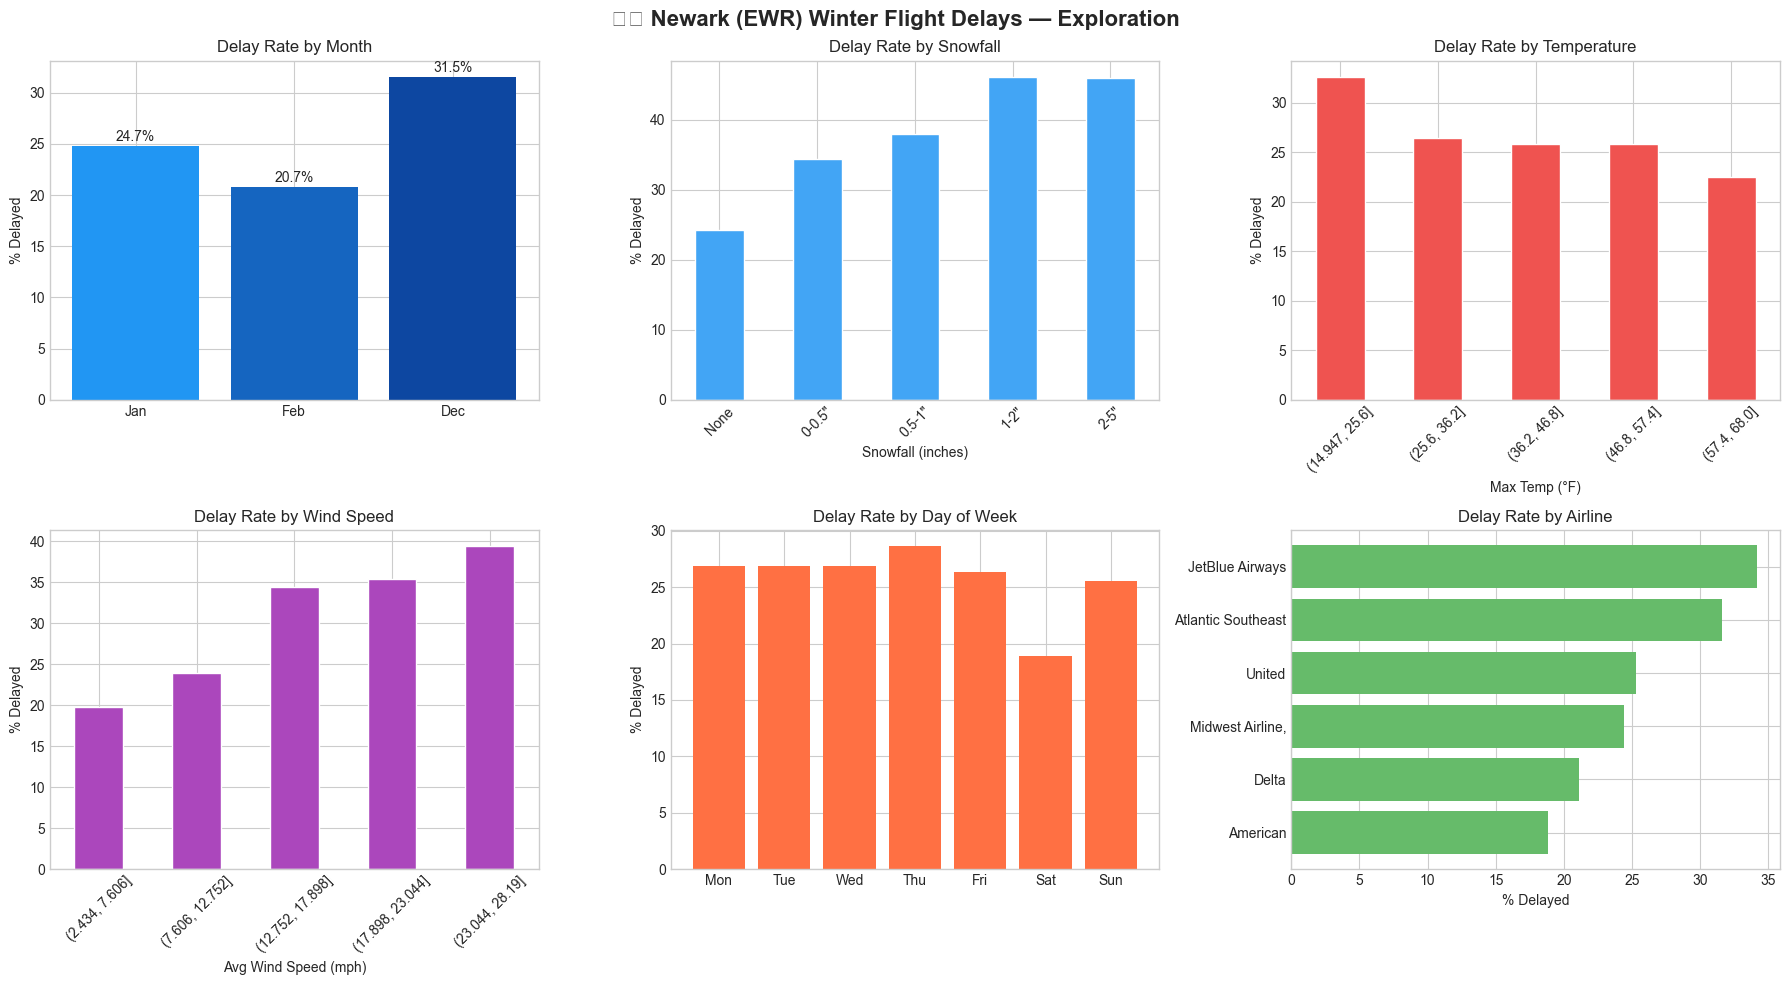

✅ Chart saved to data/eda_overview.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('❄️ Newark (EWR) Winter Flight Delays — Exploration', fontsize=16, fontweight='bold')

# Plot 1: Delay rate by Month
ax = axes[0, 0]
month_delay = winter_df.groupby('MONTH')['DELAYED'].mean() * 100
month_labels = {1: 'Jan', 2: 'Feb', 12: 'Dec'}
bars = ax.bar([month_labels.get(m, m) for m in month_delay.index], month_delay.values, color=['#2196F3', '#1565C0', '#0D47A1'])
ax.set_title('Delay Rate by Month')
ax.set_ylabel('% Delayed')
for bar, val in zip(bars, month_delay.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontsize=10)

# Plot 2: Snowfall vs Delay Rate
ax = axes[0, 1]
snow_bins = pd.cut(winter_df['SNOW'], bins=[-0.1, 0, 0.5, 1, 2, 5, 20], labels=['None', '0-0.5"', '0.5-1"', '1-2"', '2-5"', '5"+'])
snow_delay = winter_df.groupby(snow_bins, observed=True)['DELAYED'].mean() * 100
snow_delay.plot(kind='bar', ax=ax, color='#42A5F5', edgecolor='white')
ax.set_title('Delay Rate by Snowfall')
ax.set_ylabel('% Delayed')
ax.set_xlabel('Snowfall (inches)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# Plot 3: Temperature vs Delay Rate
ax = axes[0, 2]
temp_bins = pd.cut(winter_df['TMAX'], bins=5)
temp_delay = winter_df.groupby(temp_bins, observed=True)['DELAYED'].mean() * 100
temp_delay.plot(kind='bar', ax=ax, color='#EF5350', edgecolor='white')
ax.set_title('Delay Rate by Temperature')
ax.set_ylabel('% Delayed')
ax.set_xlabel('Max Temp (°F)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# Plot 4: Wind speed vs Delay Rate
ax = axes[1, 0]
wind_bins = pd.cut(winter_df['AWND'], bins=5)
wind_delay = winter_df.groupby(wind_bins, observed=True)['DELAYED'].mean() * 100
wind_delay.plot(kind='bar', ax=ax, color='#AB47BC', edgecolor='white')
ax.set_title('Delay Rate by Wind Speed')
ax.set_ylabel('% Delayed')
ax.set_xlabel('Avg Wind Speed (mph)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# Plot 5: Day of Week
ax = axes[1, 1]
dow_delay = winter_df.groupby('DAY_OF_WEEK')['DELAYED'].mean() * 100
dow_labels = {1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat', 7:'Sun'}
bars = ax.bar([dow_labels.get(d, d) for d in dow_delay.index], dow_delay.values, color='#FF7043')
ax.set_title('Delay Rate by Day of Week')
ax.set_ylabel('% Delayed')

# Plot 6: Top Airlines delay rates
ax = axes[1, 2]
top_carriers = winter_df['CARRIER_NAME'].value_counts().head(6).index
carrier_delay = winter_df[winter_df['CARRIER_NAME'].isin(top_carriers)].groupby('CARRIER_NAME')['DELAYED'].mean() * 100
carrier_delay = carrier_delay.sort_values(ascending=True)
# Shorten names for display
short_names = [name.replace(' Airlines', '').replace(' Air Lines', '').replace(' Co.', '').replace(' Inc.', '') for name in carrier_delay.index]
ax.barh(short_names, carrier_delay.values, color='#66BB6A')
ax.set_title('Delay Rate by Airline')
ax.set_xlabel('% Delayed')

plt.tight_layout()
plt.savefig('../data/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved to data/eda_overview.png')

## 📋 Step 8: Preview All Available Features

In [11]:
# Let's see everything we have to work with for modeling

print('📋 All columns available for modeling:')
print('=' * 70)
for col in winter_df.columns:
    dtype = winter_df[col].dtype
    nunique = winter_df[col].nunique()
    sample = winter_df[col].dropna().unique()[:3]
    print(f'  {col:40s} | {str(dtype):8s} | unique: {nunique:6,} | sample: {sample}')

📋 All columns available for modeling:
  MONTH                                    | int64    | unique:      3 | sample: [ 1  2 12]
  DAY_OF_WEEK                              | int64    | unique:      7 | sample: [5 2 1]
  DEP_DEL15                                | int64    | unique:      2 | sample: [0 1]
  DEP_TIME_BLK                             | object   | unique:     19 | sample: ['0800-0859' '0600-0659' '0700-0759']
  DISTANCE_GROUP                           | int64    | unique:     11 | sample: [5 3 7]
  SEGMENT_NUMBER                           | int64    | unique:      9 | sample: [1 2 3]
  CONCURRENT_FLIGHTS                       | int64    | unique:     39 | sample: [31 21 28]
  NUMBER_OF_SEATS                          | int64    | unique:     53 | sample: [110 149 129]
  CARRIER_NAME                             | object   | unique:     14 | sample: ['Delta Air Lines Inc.' 'Atlantic Southeast Airlines' 'Spirit Air Lines']
  AIRPORT_FLIGHTS_MONTH                    | int64    |

## 💾 Step 9: Save Clean Dataset

In [12]:
# Save the filtered & cleaned winter EWR dataset
output_path = '../data/ewr_winter_clean.csv'
winter_df.to_csv(output_path, index=False)

print(f'💾 Saved to: {output_path}')
print(f'   Rows: {winter_df.shape[0]:,}  |  Columns: {winter_df.shape[1]}')

💾 Saved to: ../data/ewr_winter_clean.csv
   Rows: 31,121  |  Columns: 27


In [13]:
# ===== DAY 1 SUMMARY =====

print('=' * 60)
print('📊 DAY 1 SUMMARY')
print('=' * 60)
print(f'  Original dataset:     {df.shape[0]:,} flights')
print(f'  Newark (EWR) only:    {ewr_df.shape[0]:,} flights')
print(f'  Winter months only:   {winter_df.shape[0]:,} flights')
print(f'  Delayed (>15 min):    {winter_df["DELAYED"].sum():,} ({winter_df["DELAYED"].mean()*100:.1f}%)')
print(f'  On-time:              {(winter_df["DELAYED"]==0).sum():,} ({(1-winter_df["DELAYED"].mean())*100:.1f}%)')
print(f'  Snow flights:         {(winter_df["SNOW"] > 0).sum():,}')
print(f'\n  Weather columns: PRCP, SNOW, SNWD, TMAX, AWND')
print(f'  Other features:  CARRIER_NAME, DAY_OF_WEEK, DEP_TIME_BLK,')
print(f'                   DISTANCE_GROUP, PLANE_AGE, + more')
print(f'\n  Clean data saved: {output_path}')
print('=' * 60)
print('\n🎉 Day 1 DONE! Share this output with Claude for Day 2!')

📊 DAY 1 SUMMARY
  Original dataset:     6,489,062 flights
  Newark (EWR) only:    132,478 flights
  Winter months only:   31,121 flights
  Delayed (>15 min):    8,090 (26.0%)
  On-time:              23,031 (74.0%)
  Snow flights:         4,146

  Weather columns: PRCP, SNOW, SNWD, TMAX, AWND
  Other features:  CARRIER_NAME, DAY_OF_WEEK, DEP_TIME_BLK,
                   DISTANCE_GROUP, PLANE_AGE, + more

  Clean data saved: ../data/ewr_winter_clean.csv

🎉 Day 1 DONE! Share this output with Claude for Day 2!
